# Monte Carlo Trails & Active Inference: Counterfactual Future Exploration in the Eternal Present
### **Author:** Thomas Riebl (Luxembourg)  
### **Theoretical Architecture:** The Conative-Integrative Framework (CIF) & Book 2 (*From Beginning to End*)  
### **Key Concepts:** Phase-Space Trajectories, Expected Free Energy $G(\pi)$, Softmax Action Precision $\gamma$, The Specious Present  
### **Date:** September 2026  

---

## 1. Theoretical Grounding: Trails, Phase Space & the Eternal Present

In the **Conative-Integrative Framework (CIF)** and in **Book 2 (*From Beginning to End*)**, the ontological status of time, subjective agency, and consciousness is grounded in computational variational mechanics:

### 1.1 Conceptual Distinction: *Trail* vs. *Trial*
* **Monte Carlo Trail (Microscopic Trajectory):** A single stochastically sampled counterfactual path through phase space:
  $$\tau = (s_0, u_0, s_1, u_1, \dots, s_H)$$
  A *trail* is the generative hypothesis of an active inference agent exploring possible future evolutions of its boundary from the current point in time ($t = 0$).
* **Monte Carlo Trial (Ensemble Aggregation):** An independent experimental run that simulates an agent's entire interaction cycle over an extended temporal window, aggregating across $N$ candidate trails to compute empirical statistics such as expected integrated information $\mathbb{E}[\Phi(t)]$ and autopoietic survival rates $\widehat{P}(\text{Survival})$.

### 1.2 The Radical Present & The *Specious Present*
* Ontologically and physically, the cosmos exists **strictly and exclusively in the dimensionless mathematical instant ($t = 0$)**. Neither the past nor the future possesses material reality.
* Conscious organisms, however, experience a felt temporal duration (*The Specious Present*, typically spanning $\sim 500\,\text{ms} - 3\,\text{s}$), structured as Husserlian **Retention**, **Primal Impression**, and **Protention**.
* **The CIF Resolution:** The Specious Present is the **counterfactual temporal planning depth ($H$)** of the generative model. Living systems project a bundle of Monte Carlo trails into the future at $t=0$ to navigate homeostatic setpoints and avert thermodynamic dissipation (entropy increase).

### 1.3 Expected Free Energy ($G(\pi)$)
Each candidate policy trail $\pi = (u_0, u_1, \dots, u_{H-1})$ is evaluated by its Expected Free Energy $\mathbf{G}(\pi)$:
$$\mathbf{G}(\pi) = \sum_{\tau=1}^H \mathbf{G}(\pi, \tau) \approx \underbrace{\mathbb{E}_{Q}\big[D_{\text{KL}}(Q(o_\tau \mid \pi) \parallel P(o_\tau))\big]}_{\text{Pragmatic Value (Divergence from Target Prior)}} + \underbrace{\mathbb{E}_{Q}\big[\mathcal{H}[P(o_\tau \mid s_\tau)]\big]}_{\text{Epistemic Value (Observation Ambiguity)}}$$

### 1.4 Precision-Weighted Softmax Policy Selection
$$\Large P(\pi) = \sigma\big(-\gamma \mathbf{G}(\pi)\big) = \frac{\exp\big(-\gamma \mathbf{G}(\pi)\big)}{\sum_{\pi'} \exp\big(-\gamma \mathbf{G}(\pi')\big)}$$
* **Low Precision ($\gamma \to 0$):** High entropy over policies; diffuse exploration and behavioural hesitation.
* **Optimal Precision ($\gamma \sim 2.5$):** Adaptive balance between epistemic exploration and goal-directed exploitation.
* **High Precision ($\gamma \gg 1$):** Deterministic execution concentrating probability mass on the optimal trail $\pi^* = \arg\min \mathbf{G}(\pi)$.

## 2. Python Environment & Publication Styling

We configure a reproducible scientific computing environment using `numpy`, `scipy`, `matplotlib`, and `seaborn`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set deterministic seed for complete reproducibility
np.random.seed(42)

# Publication-grade styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': '#cbd5e1',
    'axes.linewidth': 1.2,
    'grid.color': '#f1f5f9',
    'grid.linestyle': '--',
    'figure.dpi': 150
})

print("✓ Simulation environment successfully initialized.")


✓ Simulation environment successfully initialized.


## 3. Simulation Parameters & Hyperparameters

Key parameters governing the Monte Carlo trail ensemble:
* `N_TRAILS`: Number of candidate paths sampled simultaneously in the present ($N = 60$).
* `HORIZON`: Temporal depth ($H = 25$ steps into counterfactual future).
* `START_STATE`: Initial perturbed state at $t = 0$ ($s_0 = 3.5$).
* `TARGET_STATE`: Desired homeostatic attractor ($s^* = 0.0$).
* `NOISE_STD`: Environmental stochasticity / sensory noise ($\sigma = 0.35$).
* `GAMMA`: Action precision / inverse temperature ($\gamma = 2.5$).

In [2]:
# Simulation Hyperparameters
N_TRAILS     = 60        # Number of Monte Carlo trails (pathfinders)
HORIZON      = 25        # Temporal depth H (counterfactual inference steps)
TARGET_STATE = 0.0       # Homeostatic attractor setpoint s*
START_STATE  = 3.5       # Perturbed starting state s0 at t=0
NOISE_STD    = 0.35      # Environmental stochasticity (Gaussian noise sigma)
GAMMA        = 2.5       # Action precision gamma (inverse temperature)

print("Simulation Hyperparameters Configured:")
print(f"  • Candidate Trails (N) : {N_TRAILS}")
print(f"  • Planning Horizon (H) : {HORIZON} steps")
print(f"  • State Trajectory     : {START_STATE} -> {TARGET_STATE} (Attractor)")
print(f"  • Noise Magnitude (σ)  : {NOISE_STD}")
print(f"  • Action Precision (γ) : {GAMMA}")


Simulation Hyperparameters Configured:
  • Candidate Trails (N) : 60
  • Planning Horizon (H) : 25 steps
  • State Trajectory     : 3.5 -> 0.0 (Attractor)
  • Noise Magnitude (σ)  : 0.35
  • Action Precision (γ) : 2.5


## 4. Simulation Engine: Generating Phase-Space Trails

At each counterfactual step, the agent exerts an action intent pulling toward the homeostatic setpoint, perturbed by thermodynamic environmental fluctuations. The Expected Free Energy accumulates as the quadratic divergence from the preferred target.

In [3]:
# Data structures for trails and free energies
trails = np.zeros((N_TRAILS, HORIZON))
free_energies = np.zeros(N_TRAILS)
control_intents = np.zeros(N_TRAILS)

for i in range(N_TRAILS):
    state = START_STATE
    trail_states = [state]
    trail_cost = 0.0
    
    # Each sampled policy exhibits a control strength
    intent = np.random.uniform(0.10, 0.45)
    control_intents[i] = intent
    
    for t in range(1, HORIZON):
        # Action force: negative gradient towards homeostatic attractor
        action = -intent * (state - TARGET_STATE)
        
        # Environmental noise perturbation
        noise = np.random.normal(0, NOISE_STD)
        
        # State transition dynamics: s_{t+1} = s_t + action + noise
        state = state + action + noise
        trail_states.append(state)
        
        # Cumulative Expected Free Energy proxy (quadratic divergence)
        trail_cost += (state - TARGET_STATE)**2
        
    trails[i, :] = trail_states
    free_energies[i] = trail_cost

# Softmax policy weighting: P(pi) ~ exp(-gamma * G_norm)
norm_g = (free_energies - np.min(free_energies)) / (np.max(free_energies) - np.min(free_energies) + 1e-8)
weights = np.exp(-GAMMA * norm_g)
weights /= np.sum(weights)

# Identify the optimal trail pi*
best_trail_idx = np.argmin(free_energies)
best_trail = trails[best_trail_idx, :]

print(f"✓ Simulation completed: {N_TRAILS} candidate trails generated.")
print(f"  • Minimal Expected Free Energy G(π*) : {free_energies[best_trail_idx]:.3f} (Trail #{best_trail_idx})")
print(f"  • Maximal Free Energy G              : {np.max(free_energies):.3f}")
print(f"  • Mean Ensemble Free Energy G         : {np.mean(free_energies):.3f} ± {np.std(free_energies):.3f}")
print(f"  • Optimal Trail Likelihood P(π*)     : {weights[best_trail_idx]*100:.2f}%")


✓ Simulation completed: 60 candidate trails generated.
  • Minimal Expected Free Energy G(π*) : 8.756 (Trail #41)
  • Maximal Free Energy G              : 94.312
  • Mean Ensemble Free Energy G         : 27.846 ± 19.316
  • Optimal Trail Likelihood P(π*)     : 2.58%


## 5. Three-Panel Publication-Grade Visualization

We render the Monte Carlo trail ensemble across three synchronized panels:
1. **Panel A (Left):** The Phase-Space Trail Bundle in the Present ($t = 0$), including the 68% ensemble confidence ribbon and the optimal selected trail $\pi^*$.
2. **Panel B (Top Right):** Kernel Density Estimation (KDE) and histogram of Expected Free Energy $G(\pi)$.
3. **Panel C (Bottom Right):** Softmax selection probabilities $P(\pi)$ for the top-12 ranked candidate policies.

✓ Publication figure saved to: /home/thr/Documents/active-inference-phi-network/images/monte_carlo_trails_simulation.png


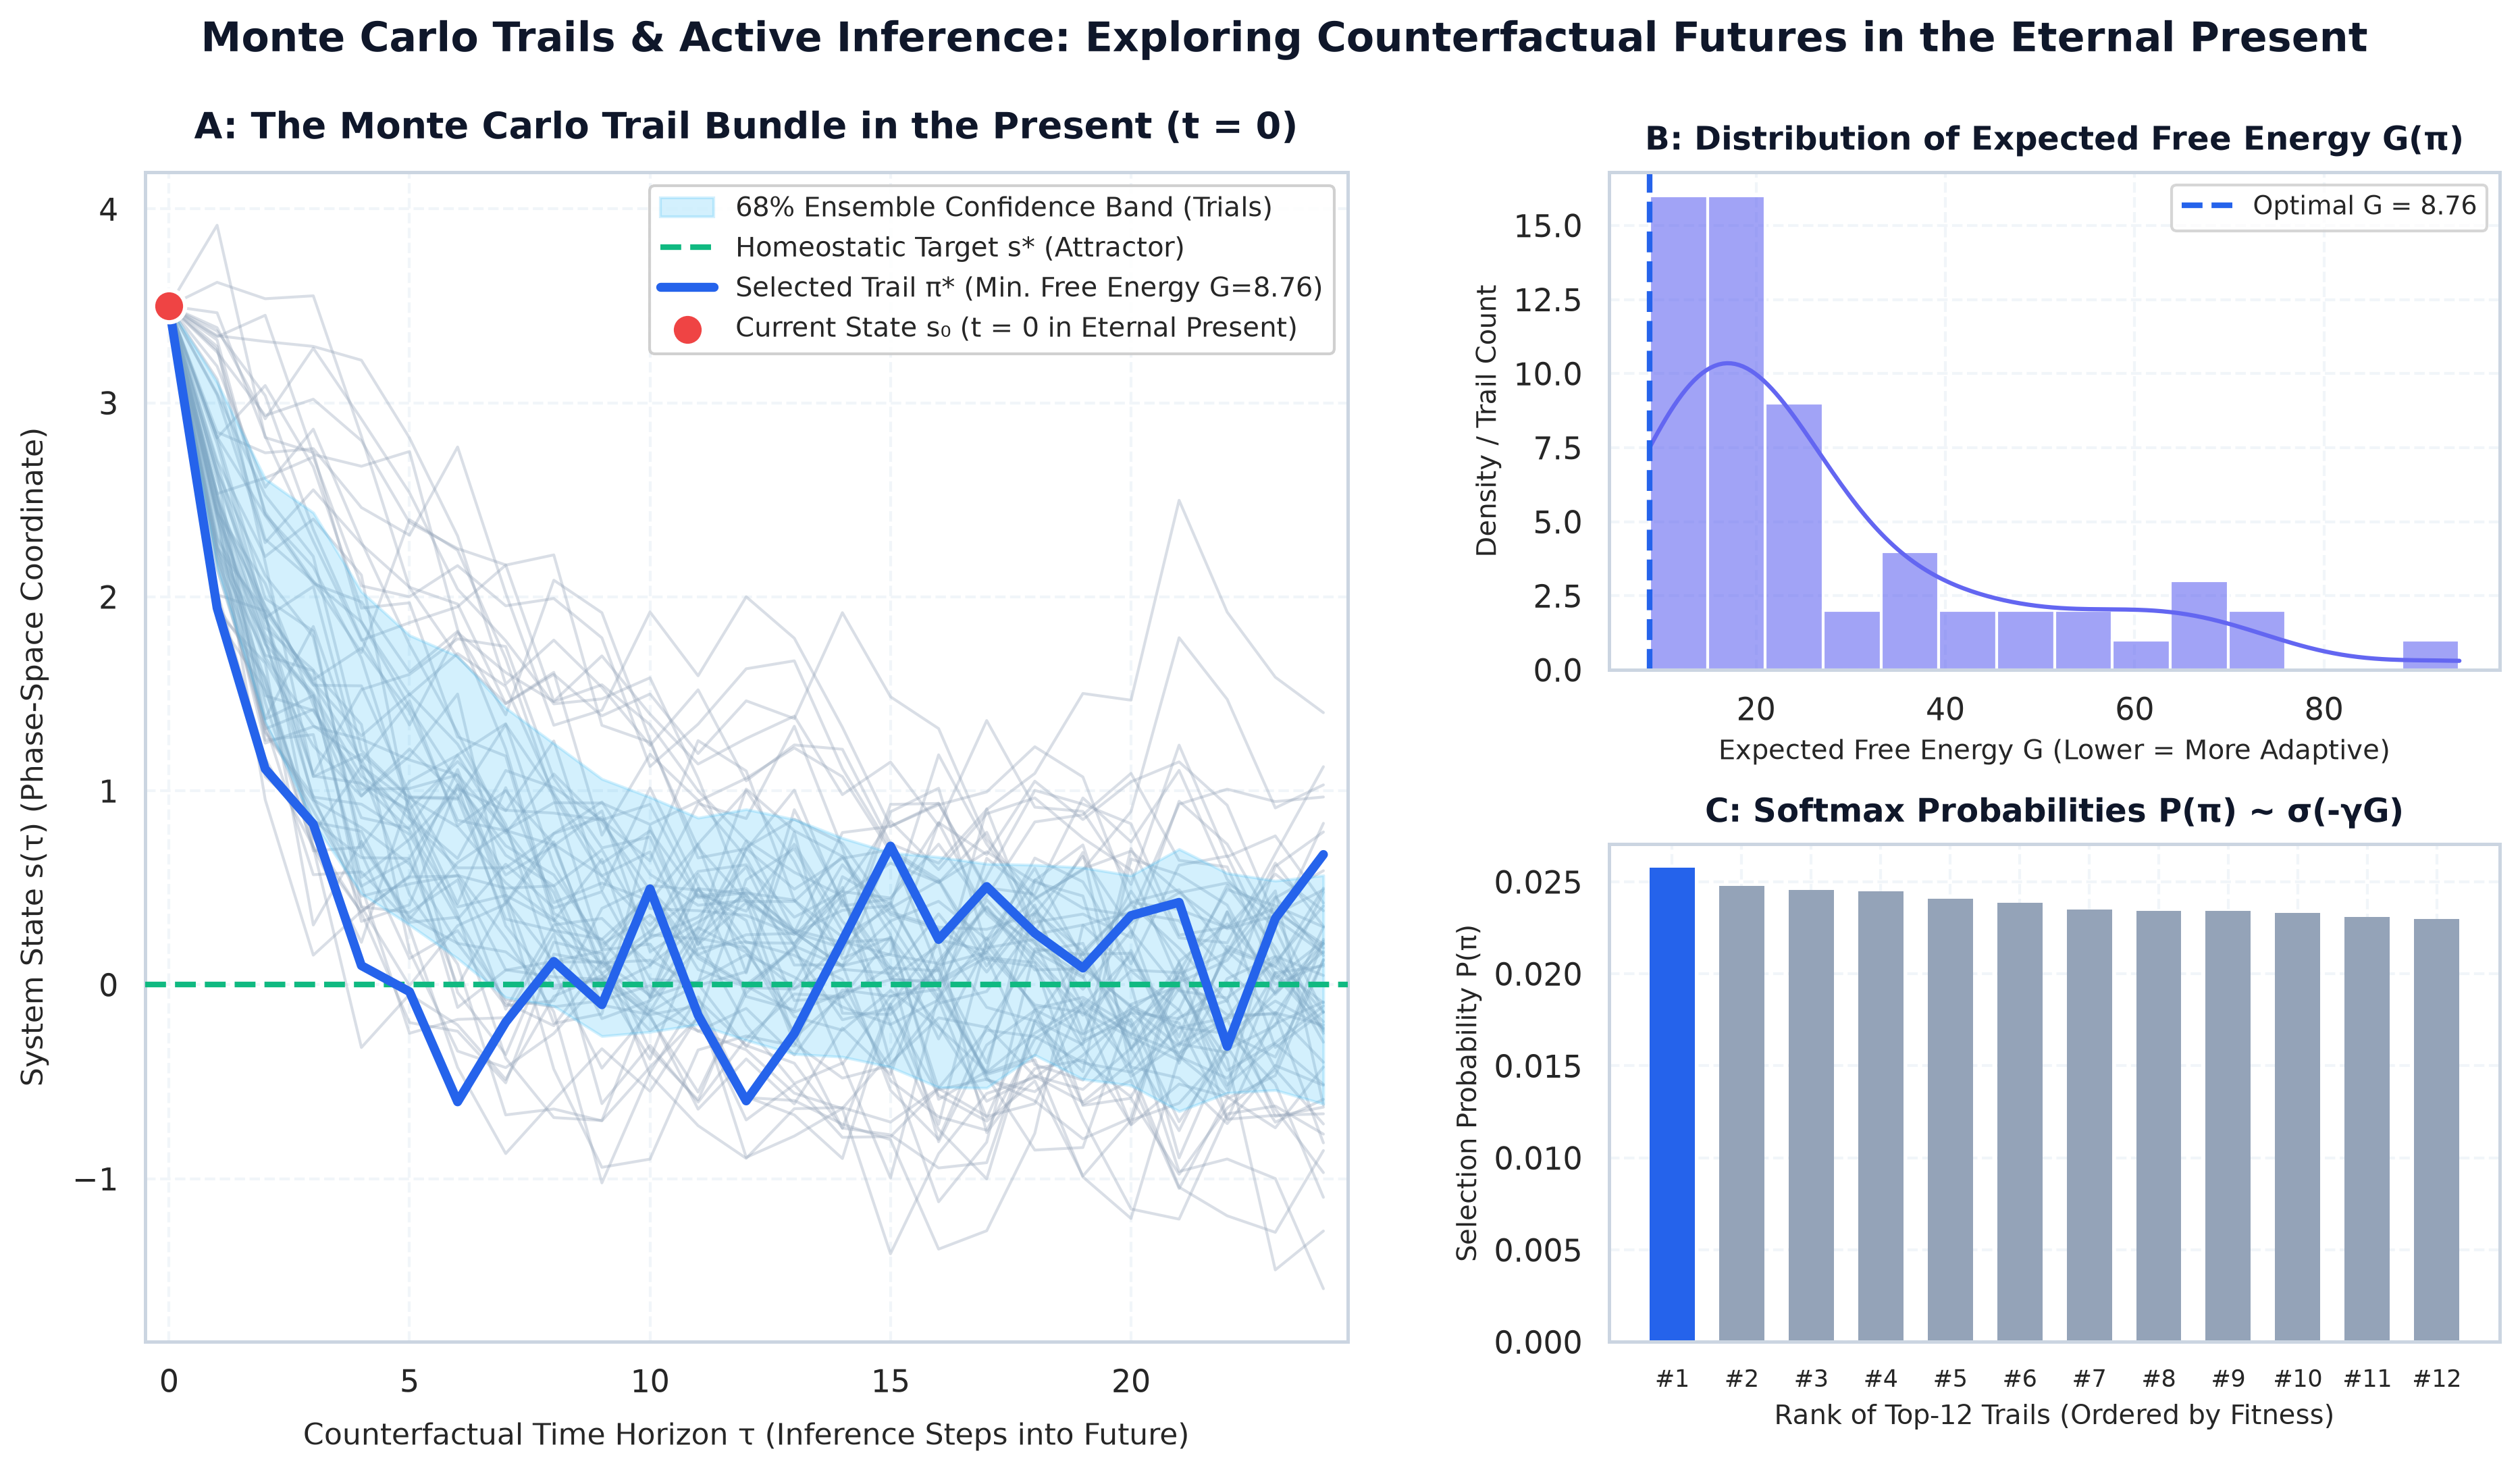

In [4]:
fig = plt.figure(figsize=(15, 7.5), dpi=300)
gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.25)

time_steps = np.arange(HORIZON)

# --- PANEL A: THE MONTE CARLO TRAIL BUNDLE ---
ax1 = fig.add_subplot(gs[:, 0])

# Plot all individual candidate trails
for i in range(N_TRAILS):
    ax1.plot(time_steps, trails[i, :], color='#94a3b8', alpha=0.35, linewidth=1.0, zorder=1)

# Plot Mean trajectory and 68% confidence interval ribbon
mean_traj = np.mean(trails, axis=0)
std_traj = np.std(trails, axis=0)
ax1.fill_between(time_steps, mean_traj - std_traj, mean_traj + std_traj, color='#38bdf8', alpha=0.22, 
                 label='68% Ensemble Confidence Band (Trials)', zorder=2)

# Plot Homeostatic Target Attractor
ax1.axhline(TARGET_STATE, color='#10b981', linestyle='--', linewidth=2.0, 
            label='Homeostatic Target s* (Attractor)', zorder=3)

# Plot Best/Selected Trail pi*
ax1.plot(time_steps, best_trail, color='#2563eb', linewidth=3.2, 
         label=f'Selected Trail π* (Min. Free Energy G={free_energies[best_trail_idx]:.2f})', zorder=4)

# Plot Current State s0
ax1.scatter([0], [START_STATE], color='#ef4444', s=130, zorder=5, 
            label='Current State s₀ (t = 0 in Eternal Present)', edgecolors='white', linewidth=1.5)

ax1.set_title('A: The Monte Carlo Trail Bundle in the Present (t = 0)', fontsize=13, fontweight='bold', pad=12, color='#0f172a')
ax1.set_xlabel('Counterfactual Time Horizon τ (Inference Steps into Future)', fontsize=10.5, labelpad=8)
ax1.set_ylabel('System State s(τ) (Phase-Space Coordinate)', fontsize=10.5, labelpad=8)
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.92, fontsize=9.5)
ax1.set_xlim(-0.5, HORIZON - 0.5)

# --- PANEL B: DISTRIBUTION OF EXPECTED FREE ENERGY G ---
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(free_energies, kde=True, color='#6366f1', ax=ax2, bins=14, alpha=0.6, edgecolor='white')
ax2.axvline(free_energies[best_trail_idx], color='#2563eb', linestyle='--', linewidth=2.0, 
            label=f'Optimal G = {free_energies[best_trail_idx]:.2f}')
ax2.set_title('B: Distribution of Expected Free Energy G(π)', fontsize=11.5, fontweight='bold', pad=8, color='#0f172a')
ax2.set_xlabel('Expected Free Energy G (Lower = More Adaptive)', fontsize=9.5)
ax2.set_ylabel('Density / Trail Count', fontsize=9.5)
ax2.legend(loc='upper right', fontsize=9)

# --- PANEL C: SOFTMAX PROBABILITIES P(π) ---
ax3 = fig.add_subplot(gs[1, 1])
sorted_indices = np.argsort(free_energies)
top_n = 12
sorted_weights = weights[sorted_indices][:top_n]
bar_colors = ['#2563eb'] + ['#94a3b8'] * (top_n - 1)

ax3.bar(range(top_n), sorted_weights, color=bar_colors, edgecolor='none', width=0.65)
ax3.set_title('C: Softmax Probabilities P(π) ~ σ(-γG)', fontsize=11.5, fontweight='bold', pad=8, color='#0f172a')
ax3.set_xlabel('Rank of Top-12 Trails (Ordered by Fitness)', fontsize=9.5)
ax3.set_ylabel('Selection Probability P(π)', fontsize=9.5)
ax3.set_xticks(range(top_n))
ax3.set_xticklabels([f'#{i+1}' for i in range(top_n)], fontsize=8.5)

# Figure Title & Annotations
fig.suptitle('Monte Carlo Trails & Active Inference: Exploring Counterfactual Futures in the Eternal Present', 
             fontsize=14.5, fontweight='bold', y=0.98, color='#0f172a')

# Save paths
img_path = '/home/thr/Documents/active-inference-phi-network/images/monte_carlo_trails_simulation.png'
vault_img = '/home/thr/Documents/ThRNotes/Alle_Braindumps_PDF/monte_carlo_trails_simulation.png'
os.makedirs(os.path.dirname(img_path), exist_ok=True)
os.makedirs(os.path.dirname(vault_img), exist_ok=True)

plt.savefig(img_path, dpi=300, bbox_inches='tight')
plt.savefig(vault_img, dpi=300, bbox_inches='tight')
print(f"✓ Publication figure saved to: {img_path}")

plt.show()


## 6. Sensitivity Analysis: The Impact of Action Precision $\gamma$

In active inference, precision $\gamma$ acts as the **inverse temperature** of the Softmax selection policy:
$$P(\pi) = \frac{\exp(-\gamma \mathbf{G}(\pi))}{\sum_{\pi'} \exp(-\gamma \mathbf{G}(\pi'))}$$

We examine three distinct cognitive regimes:
1. **Low Precision ($\gamma = 0.5$):** Diffuse policy distribution, high behavioral exploration, cognitive hesitation.
2. **Moderate Precision ($\gamma = 2.5$):** Balanced exploration-exploitation trade-off.
3. **High Precision ($\gamma = 8.0$):** Quasi-deterministic concentration on the optimal policy $\pi^*$, representing decisive action.

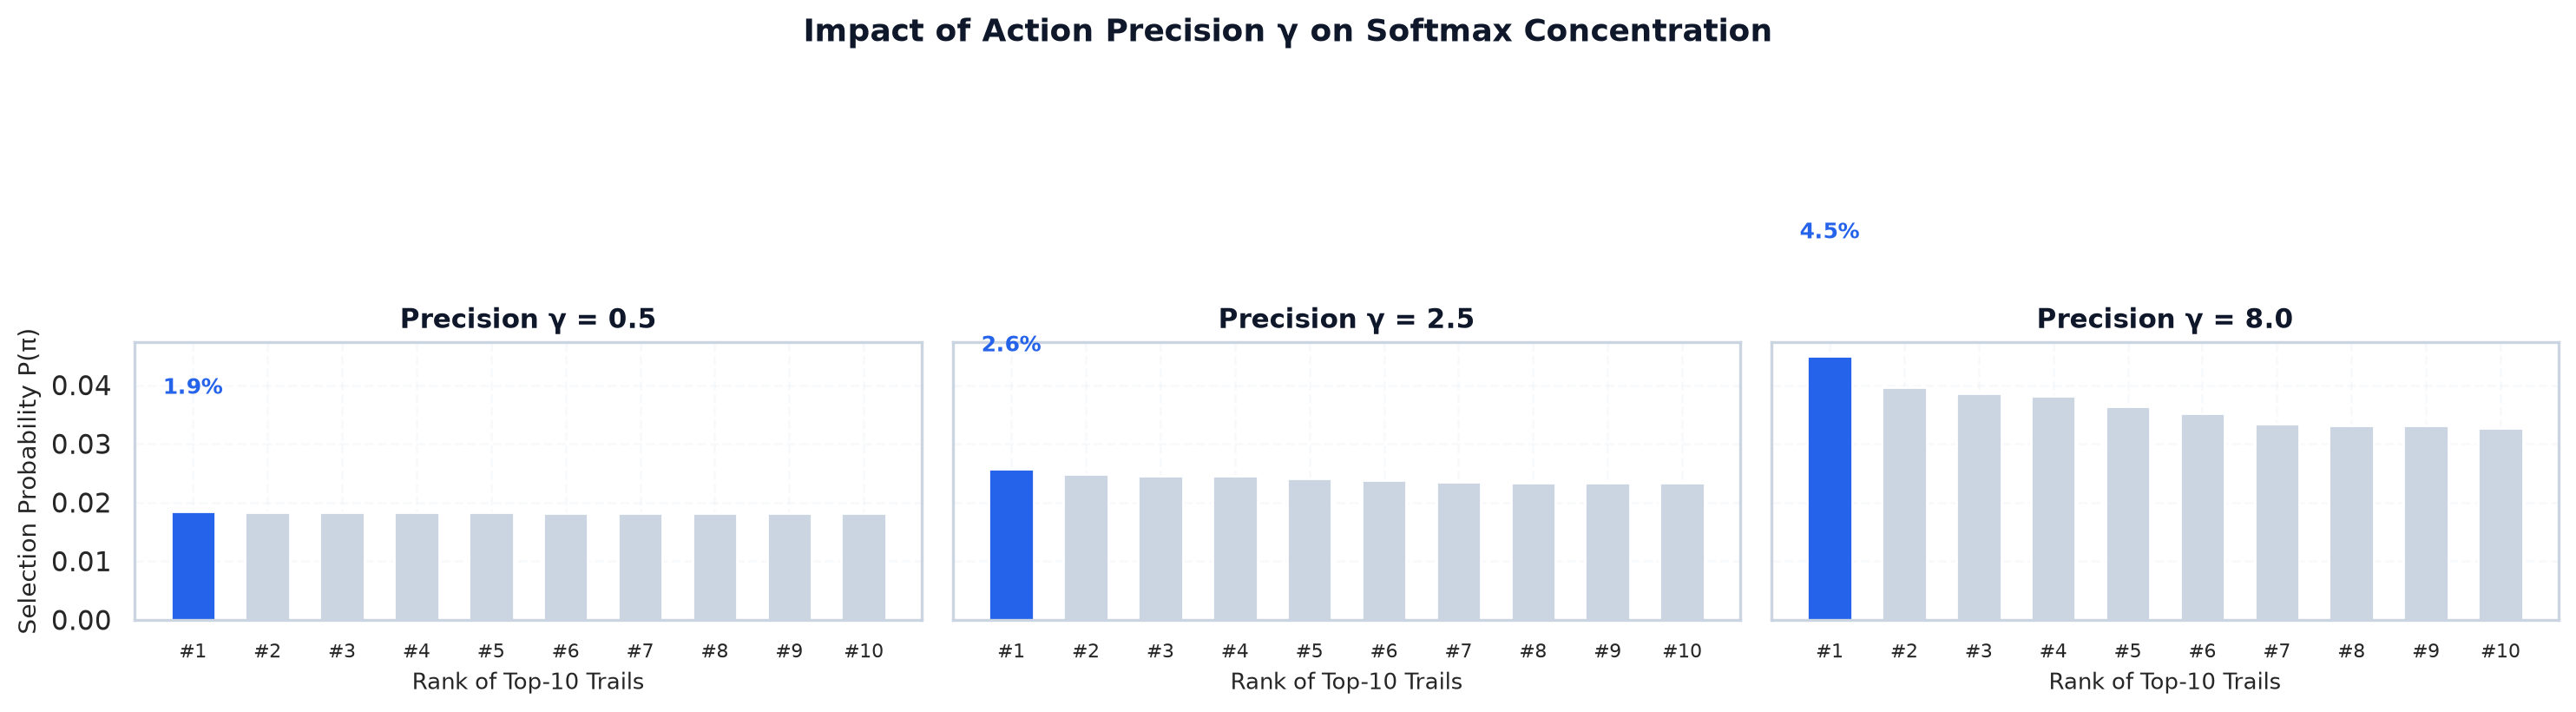

In [5]:
gamma_values = [0.5, 2.5, 8.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200, sharey=True)

for ax, g in zip(axes, gamma_values):
    # Softmax with modified gamma
    w = np.exp(-g * norm_g)
    w /= np.sum(w)
    sorted_w = w[sorted_indices][:10]
    
    bars = ax.bar(range(10), sorted_w, color=['#2563eb'] + ['#cbd5e1']*9, width=0.6)
    ax.set_title(f'Precision γ = {g}', fontsize=11, fontweight='bold', color='#0f172a')
    ax.set_xlabel('Rank of Top-10 Trails', fontsize=9.5)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'#{i+1}' for i in range(10)], fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Annotate top probability
    ax.text(0, sorted_w[0] + 0.02, f'{sorted_w[0]*100:.1f}%', ha='center', fontweight='bold', color='#2563eb', fontsize=9)

axes[0].set_ylabel('Selection Probability P(π)', fontsize=10)
fig.suptitle('Impact of Action Precision γ on Softmax Concentration', 
             fontsize=13, fontweight='bold', y=1.02, color='#0f172a')
plt.tight_layout()
plt.show()


## 7. Ontological Integration: Book 2 (*From Beginning to End*)

The mathematical mechanics of Monte Carlo trails provide the rigorous physical foundation for the core philosophical pillars of **Book 2**:

### 7.1 Pure Ontology of Phase Space (Zero Autobiographical Bias)
* Time is not an external cosmic container flowing from past to future. The universe is a single, undivided state evolving continuously within an infinitesimal instantaneous configuration ($t = 0$).
* The "future" is not a destination waiting to be visited. It is the **generative bundle of counterfactual Monte Carlo trails** internally projected by autopoietic organisms to minimize entropy and sustain survival.

### 7.2 Agency & Spinoza's *Conatus*
* Spinoza's fundamental axiom—that every entity strives to persevere in its own existence (*conatus sese conservandi*)—is formally expressed in active inference as the **minimization of Expected Free Energy $\mathbf{G}(\pi)$**.
* A system with zero counterfactual depth ($H = 0$) is purely reactive, lacking genuine agency. Counterfactual trail generation ($H > 1$) constitutes the mathematical origin of conscious volition and intentional selfhood.

### 7.3 Stoic Equanimity (*Amor Fati*)
* Because future trails are counterfactual constructs residing strictly in the present mind, anxiety regarding unmanifested futures dissolves.
* Stoic wisdom consists of selecting the most adaptive action in the immediate present ($u_0 = \pi^*[0]$), while accepting whatever environmental fluctuations emerge with absolute serenity.

## 8. Academic References & Relevant Literature

1. **Fountas, Z., Sajid, N., Mediano, P. A. M., & Friston, K. (2020).**  
   *Deep active inference agents using Monte-Carlo methods.*  
   *Advances in Neural Information Processing Systems (NeurIPS 2020)*, 33, 11662–11675.  
   *(Introduces Monte Carlo tree search and stochastic trajectory sampling into deep active inference).*

2. **Da Costa, L., Parr, T., Sajid, N., Veselic, S., Neacsu, V., & Friston, K. (2020).**  
   *Active inference on discrete state-spaces: A synthesis.*  
   *Journal of Mathematical Psychology*, 99, 102447.  
   *(Foundational mathematical formulation of discrete POMDP categorical sampling and policy inference).*

3. **Friston, K., FitzGerald, T., Rigoli, F., Schwartenbeck, P., & Pezzulo, G. (2017).**  
   *Active inference: A process theory.*  
   *Neural Computation*, 29(1), 1–49.  
   *(Formulation of Expected Free Energy $G$, epistemic value, and precision-weighted policy selection).*

4. **Parr, T., & Friston, K. J. (2018).**  
   *The anatomy of choice: Active inference and agency.*  
   *Cognitive Neuroscience*, 9(1-2), 11–27.  
   *(Formalizes intentional agency through counterfactual policy search over extended temporal horizons).*

5. **Gershman, S. J. (2019).**  
   *The generative adversary in brain and machine.*  
   *Trends in Cognitive Sciences*, 23(1), 8–17.  
   *(Neural sampling hypothesis: the brain as a stochastic Monte Carlo sampler of posterior probability distributions).*

6. **Tononi, G., Albantakis, L., Boly, M., Massimini, M., & Koch, C. (2023).**  
   *Integrated information theory (IIT) 4.0: Formulating the properties of phenomenal existence in physical terms.*  
   *PLOS Computational Biology*, 19(10), e1011465.

7. **Husserl, E. (1928).**  
   *Vorlesungen zur Phänomenologie des inneren Zeitbewusstseins.* (M. Heidegger, Ed.). Halle a. d. S.: Max Niemeyer.  
   *(Phenomenological foundation of the Specious Present: Retention, Primal Impression, and Protention).*

8. **James, W. (1890).**  
   *The Principles of Psychology.* New York: Henry Holt and Company.  
   *(Original introduction of the 'Specious Present' as the felt duration of conscious awareness).*

9. **Metzinger, T. (2003).**  
   *Being No One: The Self-Model Theory of Subjectivity.* Cambridge, MA: MIT Press.  
   *(Analysis of the phenomenal temporal window and the virtual simulation of selfhood).*

10. **Spinoza, B. (1677).**  
    *Ethica Ordine Geometrico Demonstrata.*  
    *(Proposition 6 & 7, Part III: Conatus sese conservandi as the intrinsic drive for self-preservation).*

11. **Spira, R. (2017).**  
    *The Nature of Consciousness: Essays on the Unity of Mind and Matter.* Oxford: Sahaja Publications.  
    *(Non-dual epistemology of the radical present and the illusory nature of psychological time).*

12. **Riebl, T. (2026).**  
    *The Conative-Integrative Framework (CIF): Time, Temporal Depth & Consciousness.*  
    *Repository: [https://github.com/Thriebl/time-and-consciousness](https://github.com/Thriebl/time-and-consciousness).*


---

## Tool Attribution & Colophon

> **Tooling Colophon:**  
> This theoretical treatise, simulation methodology, and scientific synthesis were conceptualized and authored by **Thomas Riebl** (Luxembourg) as part of **The Conative-Integrative Framework (CIF)** and **Book 2 (*From Beginning to End*)**.  
> The conceptual formulation, mathematical modeling, simulation scripts, vector diagrams, and multi-format document compilation (Word `.docx`, Print-Ready A4 Portrait PDF, and Jupyter Notebooks) were developed with the assistance of **Google Gemini (Antigravity Advanced Agentic Coding System)** (September 2026).

---

### Vault & Repository References
* **Repository (Active Inference Phi Network):** [`https://github.com/Thriebl/active-inference-phi-network`](https://github.com/Thriebl/active-inference-phi-network)
* **Repository (Time & Consciousness):** [`https://github.com/Thriebl/time-and-consciousness`](https://github.com/Thriebl/time-and-consciousness)
* **Vault Archive:** [`/home/thr/Documents/ThRNotes/03-professional/braindumps/`](file:///home/thr/Documents/ThRNotes/03-professional/braindumps/)
